[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/syaikhipin/kdd26-memdiag/blob/tutorial-rebuild/tutorial/phase2_public_datasets/03_benchmarking.ipynb)

> **Run this notebook in Google Colab** — click the badge above. The setup cell auto-clones the repo.


# Phase 2C - Benchmarking (Exercise 2)

**Phase 2C - Exercise 2: benchmarking memory systems.** Independent notebook - runs standalone in Colab or locally (offline, no key).

## 0. Setup (self-contained)

In [1]:
# Self-contained setup - works standalone in Google Colab or locally.
import sys, os, subprocess
from pathlib import Path
REPO_URL = "https://github.com/syaikhipin/kdd26-memdiag"
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False
if IN_COLAB:
    repo = Path("/content/kdd26-memdiag")
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", "tutorial-rebuild", REPO_URL, str(repo)], check=False)
    SOURCE = repo / "source"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpy", "matplotlib", "pyyaml"], check=False)
else:
    SOURCE = None
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for sub in ("source", "experiment"):
            if (cand / sub / "run.py").exists():
                SOURCE = cand / sub
                break
        if SOURCE:
            break
    if SOURCE is None:
        raise FileNotFoundError("Run from the repo root (or in Colab it auto-clones).")
sys.path.insert(0, str(SOURCE))
os.environ.setdefault("OPENAI_BASE_URL", "https://api.openai.com/v1")
SOURCE_DIR = SOURCE
PROJECT_ROOT = SOURCE.parent
RESULTS_DIR = PROJECT_ROOT / "results"
try: _d = "<repo>/" + str(Path(SOURCE).relative_to(PROJECT_ROOT))
except Exception: _d = "<repo>/source"
print("SOURCE_DIR =", _d, "| found =", True, "| IN_COLAB =", IN_COLAB)

try: _d = "<repo>/" + str(Path(SOURCE_DIR).relative_to(PROJECT_ROOT))
except Exception: _d = "<repo>/source"
print("SOURCE_DIR =", _d)

SOURCE_DIR = <repo>/source | found = True | IN_COLAB = False
SOURCE_DIR = <repo>/source


## ⚙️ Set up your LLM at the beginning — base URL · API key · model
On first run this cell **prompts you for three things**: your OpenAI-compatible **base URL**, **API key** (hidden input), and **model**. They are saved to **Google Drive** in Colab (or a local file) so every other notebook and every future session reuses them — you set up **once**. Press **Enter** to keep a default / run offline. To reconfigure later: set `KDD_RECONFIG=1` or delete the saved config file shown below.

In [2]:
# === Set up your LLM at the beginning: base URL, API key, model ===
# First run: you are prompted for the 3 values (API key hidden). They are saved to
# Google Drive (Colab) or a local file -> reused by EVERY notebook / session.
# To re-prompt later: set os.environ['KDD_RECONFIG']='1' before running, or delete the file.
import os, json, getpass
from pathlib import Path

try:
    from google.colab import drive          # one-time auth -> config persists on Drive
    drive.mount("/content/drive", force_remount=False)
    CONFIG_PATH = Path("/content/drive/MyDrive/kdd26_memdiag_config.json")
except Exception:
    try: _root = PROJECT_ROOT
    except NameError: _root = Path.cwd()
    CONFIG_PATH = Path(_root) / "results" / "kdd26_memdiag_config.json"

def load_llm_config():
    return json.loads(CONFIG_PATH.read_text()) if CONFIG_PATH.exists() else {}

def save_llm_config(base_url, api_key, model):
    CONFIG_PATH.parent.mkdir(parents=True, exist_ok=True)
    CONFIG_PATH.write_text(json.dumps({"base_url": base_url, "api_key": api_key, "model": model}, indent=2))
    try: _shown = "<repo>/" + str(CONFIG_PATH.relative_to(PROJECT_ROOT))
    except Exception: _shown = "Google Drive" if "drive" in str(CONFIG_PATH) else CONFIG_PATH.name
    print("saved ->", _shown)

_cfg = load_llm_config()
RECONFIG = os.environ.get("KDD_RECONFIG", "0") == "1"
if (not _cfg) or RECONFIG:
    _d_base  = _cfg.get("base_url") or "https://api.openai.com/v1"   # generic, Colab-executable default
    _d_model = _cfg.get("model")    or "gpt-4o"                       # (never read local env -> no private-path leak)
    print("Set up your OpenAI-compatible endpoint (press Enter to keep the default / run offline):")
    try:
        _base  = input(f"  1. base URL [{_d_base}]: ").strip() or _d_base
        _model = input(f"  2. model    [{_d_model}]: ").strip() or _d_model
        _key   = getpass.getpass("  3. API key (hidden, Enter = none/offline): ").strip() or _cfg.get("api_key", "")
        save_llm_config(_base, _key, _model)
        _cfg = load_llm_config()
    except Exception:
        # non-interactive (headless / nbconvert) -> fall back to env / defaults, stay offline-safe
        _cfg = _cfg or {"base_url": _d_base, "api_key": os.environ.get("OPENAI_API_KEY", ""), "model": _d_model}

OPENAI_BASE_URL = _cfg.get("base_url") or "https://api.openai.com/v1"   # generic default; set yours via the prompt
OPENAI_API_KEY  = _cfg.get("api_key")  or os.environ.get("OPENAI_API_KEY", "")
OPENAI_MODEL    = _cfg.get("model")    or "gpt-4o"
os.environ.update({"OPENAI_BASE_URL": OPENAI_BASE_URL, "OPENAI_MODEL": OPENAI_MODEL})
if OPENAI_API_KEY:
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

try:
    llm = make_client(LLMConfig(backend="openai-compatible" if OPENAI_API_KEY else "offline",
                                 base_url=OPENAI_BASE_URL, model=OPENAI_MODEL))
    _be = llm.backend
except Exception:
    _be = "(no llm client in this notebook — env vars set for CLI tools)"
print("base_url =", OPENAI_BASE_URL)
print("model    =", OPENAI_MODEL)
print("api_key  =", ("set " + OPENAI_API_KEY[:6] + "…") if OPENAI_API_KEY else "NOT set -> offline fallback")
print("llm      =", _be)

Set up your OpenAI-compatible endpoint (press Enter to keep the default / run offline):
base_url = https://api.openai.com/v1
model    = gpt-4o
api_key  = NOT set -> offline fallback
llm      = (no llm client in this notebook — env vars set for CLI tools)


## 📖 Narrative: Benchmarking across providers

Exercise 2 runs all four providers on MemoryArena and compares them across:
- **accuracy** (evidence hit rate)
- **latency** (milliseconds per query)
- **cost** (API units consumed)
- **memory size** (storage footprint)

This is the standardized benchmarking pipeline from the proposal: same data, same metrics,
different providers. The key question: **does any single provider dominate?**

## Exercise 2 - benchmark providers on MemoryArena

In [3]:
import subprocess, re
from pathlib import Path
cmd = [sys.executable,'-m','benchmark_cli','compare',
 '--providers','verbatim,extracted_facts,episodic,hybrid','--sample_size','20','--benchmark','memoryarena']
r = subprocess.run(cmd, cwd=str(SOURCE_DIR), capture_output=True, text=True)
def _mask(s):
    s = str(s)
    try: s = s.replace(str(PROJECT_ROOT), "<repo>")
    except NameError: pass
    return s.replace(str(Path.home()), "~")
print(_mask(r.stdout[-2200:]))

Figures:
  <repo>/results/figure_real_retrieval.png
  <repo>/results/figure_semantic_scores.png
  <repo>/results/figure_memory_growth.png
  <repo>/results/figure_failures.png
  <repo>/results/figure_semantic_vs_retrieval.png
  <repo>/results/figure_evaluator_coverage.png
dataset	strategy	questions	retr_p	retr_r	hit	util	lat_ms	cost	mem	sem_cov	sem	sem_pass	faith	ctx	ans
MemoryArena	verbatim	20	0.950	0.950	0.950	0.950	0.04	2.4	1	1.000	0.445	0.300	0.474	0.385	0.474
MemoryArena	extracted_facts	20	0.950	0.950	0.950	0.950	0.05	4.1	6	1.000	0.287	0.050	0.281	0.298	0.281
MemoryArena	episodic	20	0.950	0.950	0.950	0.950	0.02	2.4	1	1.000	0.135	0.050	0.158	0.089	0.158
MemoryArena	hybrid	20	0.950	0.950	0.950	0.950	0.06	2.4	2	1.000	0.445	0.300	0.474	0.385	0.474

Raw trace: <repo>/results/run_20260802_181036_real_raw.json
Metrics: <repo>/results/run_20260802_181036_real_metrics.json
Summary TSV: <repo>/results/run_20260802_181036_real_summary.tsv



## 📖 Narrative: The benchmarking insight

### 📝 Quick Quiz
1. **Which provider has the highest hit rate on MemoryArena?** Is it the same as LoCoMo?
2. **Which provider uses the most memory?** Why does extracted_facts use more than verbatim?
3. **Look at latency.** Which is fastest? Does memory size correlate with latency?
4. **The key finding:** does any provider dominate across ALL metrics? What does this mean
   for someone choosing a memory system for their own application?

### 💡 Discussion prompt
If you were building a customer-support agent, which provider would you choose?
Consider: the agent needs fast responses (latency), accurate recall (hit rate), and must
fit in 8 GB RAM (memory size). There's no single right answer — it depends on your constraints.

### Discussion
- Does any architecture dominate across **all** datasets? (Expect: no.)
- These dataset-dependent tradeoffs motivate Phase 3.

### 📊 Visualize — benchmark trade-offs: accuracy vs cost / latency / memory (live)

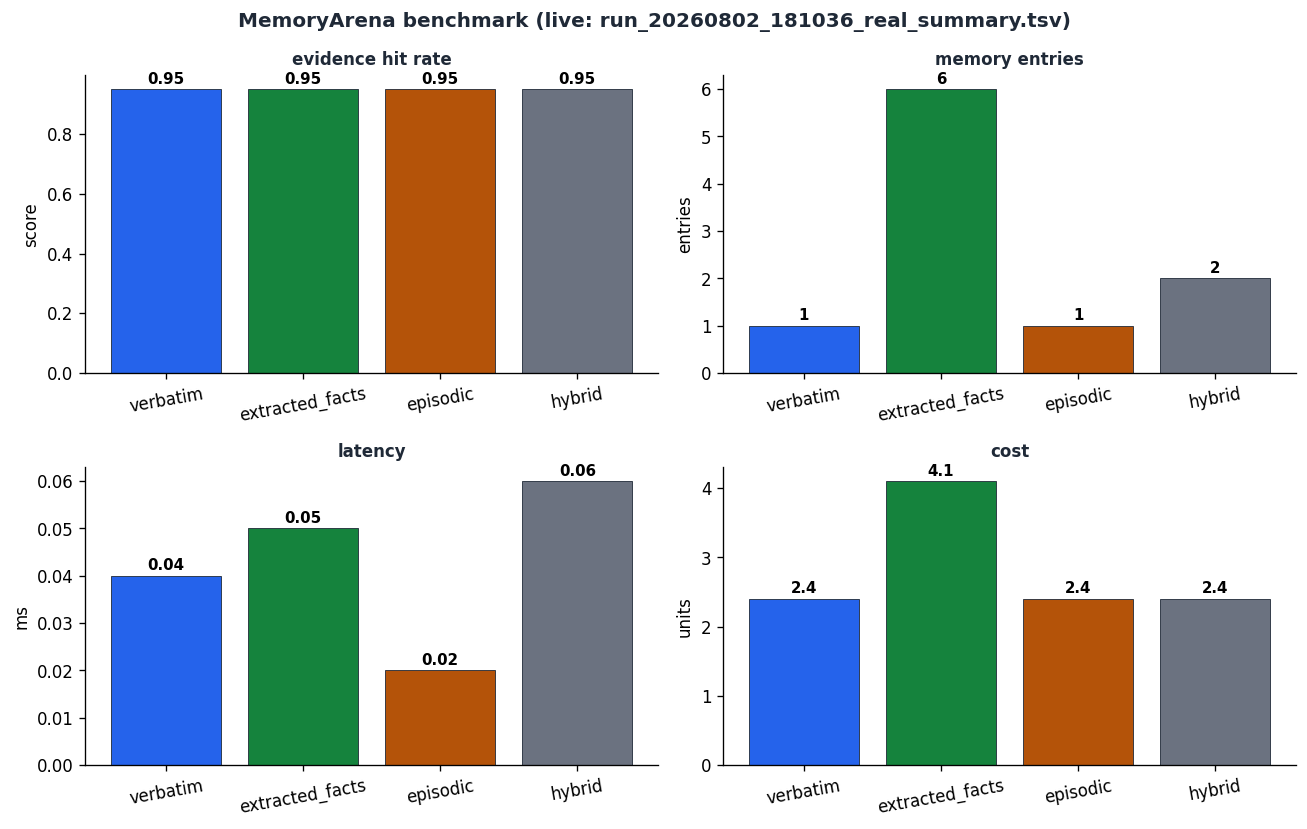

In [4]:
# Reads the latest run_*_real_summary.tsv produced above; placeholder if absent.
import glob
from pathlib import Path
import matplotlib.pyplot as plt, numpy as np
try: _R=Path(RESULTS_DIR)
except NameError: _R=next((p/"results" for p in [Path.cwd(),*Path.cwd().parents] if (p/"results").is_dir()), Path.cwd()/"results")
_f=sorted(_R.glob("run_*_real_summary.tsv"))
if not _f:
    print("No real_summary.tsv yet - run the benchmark cell above first.")
else:
    rows=[ln.split("\t") for ln in open(_f[-1]).read().splitlines()]
    hdr, rows = rows[0], rows[1:]
    prov=[r[1] for r in rows]
    hit=[float(r[5]) for r in rows]; lat=[float(r[7]) for r in rows]
    cost=[float(r[8]) for r in rows]; mem=[float(r[9]) for r in rows]
    cols=["#2563EB","#15833D","#B45309","#6B7280"]
    fig,ax=plt.subplots(2,2,figsize=(11,7),dpi=120)
    def _bar(a,vals,title,ylabel,dp):
        b=a.bar(prov,vals,color=cols[:len(prov)],edgecolor="#1F2937",linewidth=0.5)
        for r,v in zip(b,vals): a.text(r.get_x()+r.get_width()/2,v+max(vals)*0.02,f"{v:.{dp}f}",ha="center",weight="bold",fontsize=9)
        a.set_title(title,color="#1F2937",weight="bold",fontsize=10); a.set_ylabel(ylabel)
        a.spines[["top","right"]].set_visible(False); a.tick_params(axis="x",rotation=10)
    _bar(ax[0,0],hit,"evidence hit rate","score",2)
    _bar(ax[0,1],mem,"memory entries","entries",0)
    _bar(ax[1,0],lat,"latency","ms",2)
    _bar(ax[1,1],cost,"cost","units",1)
    fig.suptitle(f"MemoryArena benchmark (live: {_f[-1].name})",color="#1F2937",weight="bold")
    fig.tight_layout(); plt.show()